## L'Eua Claire
### Fecal Coliform (Phannet)
## Group 5
## Team Members
| Name | Student's ID |
|---|---|
| Rith Theary | e20231141 |
| Roeurn Phannet | e20230799 |
| Meth Sreyka | e20230172 |

> **Goal:** Train 5 regression models then compare with 5-Fold CV next predict Fecal Coliform then  
> classify water as **Safe / Not Safe** (threshold = 50 MPN/100 mL).


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, classification_report, confusion_matrix)
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)
print("Libraries loaded.")
from sklearn.preprocessing import QuantileTransformer

Libraries loaded.


In [2]:
import os

file_path = r"D:\mini_water_predict\Dataset\water_quality_cleandataversion.csv"

print(os.path.exists(file_path))

True


## Load Cleaned Data

In [3]:
df = pd.read_csv(r"D:\mini_water_predict\Dataset\water_quality_cleandataversion.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()

Loaded: 2,617 rows × 23 columns
Columns: ['Water_Body_Type', 'State_Name', 'Year', 'Temperature', 'DO', 'pH', 'Conductivity', 'BOD', 'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'Total_Coliform_log', 'Fecal_Coliform_log', 'DO_sqrt', 'BOD_Temp', 'BOD_Conductivity', 'Nitrate_Temp', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Is_Monsoon']


,Water_Body_Type,State_Name,Year,Temperature,DO,pH,Conductivity,BOD,Nitrate_Nitrite,Fecal_Coliform,...,Nitrate_Nitrite_log,Total_Coliform_log,Fecal_Coliform_log,DO_sqrt,BOD_Temp,BOD_Conductivity,Nitrate_Temp,BOD_Temp_log,BOD_Conductivity_log,Is_Monsoon
0,LAKE,ANDHRA PRADESH,2017,26.0000,6.3500,7.6500,815.5000,1.8000,2.2600,20.0000,...,1.1817,7.2269,3.0445,2.5199,46.8000,1467.9000,58.7600,3.8670,7.2923,1
1,LAKE,ASSAM,2017,23.5000,4.7000,6.6000,89.0000,8.6000,0.9000,1150.0000,...,0.6419,8.1259,7.0484,2.1679,202.1000,765.4000,21.1500,5.3137,6.6417,1
2,LAKE,ASSAM,2017,29.0000,5.5500,7.2000,103.5000,1.8500,0.7500,750.0000,...,0.5596,7.9377,6.6214,2.3558,53.6500,191.4750,21.7500,4.0009,5.2600,1
3,POND,ASSAM,2017,28.0000,2.6500,7.6000,617.5000,9.6000,3.2500,2300.0000,...,1.4469,9.2934,7.7411,1.6279,268.8000,5928.0000,91.0000,5.5977,8.6876,1
4,POND,ASSAM,2017,27.5000,5.1500,6.7000,130.5000,10.1500,1.2000,1200.0000,...,0.7885,9.5943,7.0909,2.2694,279.1250,1324.5750,33.0000,5.6352,7.1896,1


## Feature Selection & Encoding

**Column contract (must match EDA output):**

| Feature | Column used in model |
|---|---|
| Temperature | `Temperature` |
| Dissolved Oxygen | `DO_sqrt` |
| pH | `pH` |
| Conductivity | `Conductivity_log` |
| BOD | `BOD_log` |
| Nitrate/Nitrite | `Nitrate_Nitrite_log` |
| Water body type | One-hot from `Water_Body_Type` |
| State | Frequency-encoded from `State_Name` |

**No winsorizing done once in EDA.**

In [4]:
df.columns

Index(['Water_Body_Type', 'State_Name', 'Year', 'Temperature', 'DO', 'pH',
       'Conductivity', 'BOD', 'Nitrate_Nitrite', 'Fecal_Coliform',
       'Total_Coliform', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log',
       'Total_Coliform_log', 'Fecal_Coliform_log', 'DO_sqrt', 'BOD_Temp',
       'BOD_Conductivity', 'Nitrate_Temp', 'BOD_Temp_log',
       'BOD_Conductivity_log', 'Is_Monsoon'],
      dtype='object')

In [5]:
# Drop leakage and non-feature columns
DROP_COLS = ['Total_Coliform', 'Total_Coliform_log',
             'Fecal_Coliform_log',           # log of target not a feature
             'DO',                            # raw version; using DO_sqrt
             'Conductivity', 'BOD', 'Nitrate_Nitrite',  # raw; using _log versions
             'State_WaterType', 'Is_Monsoon']               # composite label, not a feature
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True, errors='ignore')
print("After dropping leakage/redundant columns:")
print(df.columns.tolist())

After dropping leakage/redundant columns:
['Water_Body_Type', 'State_Name', 'Year', 'Temperature', 'pH', 'Fecal_Coliform', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'DO_sqrt', 'BOD_Temp', 'BOD_Conductivity', 'Nitrate_Temp', 'BOD_Temp_log', 'BOD_Conductivity_log']


In [6]:
# Validate that all required feature columns exist
REQUIRED_FEATURES = ['Temperature', 'DO_sqrt', 'pH',
                     'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log']

missing = [c for c in REQUIRED_FEATURES if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns check EDA notebook output: {missing}")
else:
    print("All required feature columns present.")
    print(REQUIRED_FEATURES)

All required feature columns present.
['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log']


In [7]:
# One-hot encode Water_Body_Type
if 'Water_Body_Type' in df.columns:
    df = pd.get_dummies(df, columns=['Water_Body_Type'], drop_first=True)
    wb_dummies = [c for c in df.columns if c.startswith('Water_Body_Type_')]
    print("Water body dummies created:", wb_dummies)
else:
    wb_dummies = []
    print("Water_Body_Type column not found skipping one-hot encoding.")

HAS_STATE = 'State_Name' in df.columns
extra_cols = wb_dummies + (['State_freq'] if HAS_STATE else [])

FEATURE_COLS = REQUIRED_FEATURES + extra_cols
NEW_FEATURES = ['BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp', 'Is_Monsoon']
for f in NEW_FEATURES:
    if f in df.columns:
        FEATURE_COLS.append(f)
print("\nFinal feature list:", FEATURE_COLS)

Water body dummies created: ['Water_Body_Type_POND', 'Water_Body_Type_TANK', 'Water_Body_Type_WETLAND']

Final feature list: ['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'Water_Body_Type_POND', 'Water_Body_Type_TANK', 'Water_Body_Type_WETLAND', 'State_freq', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp']


## Define X and y

In [15]:
TARGET = 'Fecal_Coliform'

# Build X
FEATURE_COLS_PRE_SPLIT = [c for c in FEATURE_COLS if c != 'State_freq']

X = df[FEATURE_COLS_PRE_SPLIT].copy()

if HAS_STATE:
    X['State_Name_raw'] = df['State_Name']

y_raw = df[TARGET].copy()

print(f"Features : {len(FEATURE_COLS)}")
print(f"X shape  : {X.shape}")
print(f"y (raw)  : min={y_raw.min():.1f}  max={y_raw.max():.1f}  median={y_raw.median():.1f}")
print(f"y skew   : {y_raw.skew():.3f}")

Features : 13
X shape  : (2617, 13)
y (raw)  : min=1.0  max=1779500.0  median=250.0
y skew   : 7.442


## Train/Test Split + K-Fold Setup

In [16]:
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X,
    y_raw,
    test_size=0.2,
    random_state=42
)
if HAS_STATE:

    state_freq_map = X_train['State_Name_raw'].value_counts(normalize=True)

    fallback_freq = state_freq_map.min()

    X_train['State_freq'] = (
        X_train['State_Name_raw']
        .map(state_freq_map)
    )

    X_test['State_freq'] = (
        X_test['State_Name_raw']
        .map(state_freq_map)
        .fillna(fallback_freq)
    )

    X_train.drop(columns=['State_Name_raw'], inplace=True)

    X_test.drop(columns=['State_Name_raw'], inplace=True)

else:
    FEATURE_COLS = [c for c in FEATURE_COLS if c != 'State_freq']

X_train = X_train[FEATURE_COLS]
X_test = X_test[FEATURE_COLS]

qt = QuantileTransformer(
    output_distribution='normal',
    random_state=42
)

y_train = qt.fit_transform(
    y_train_raw.values.reshape(-1, 1)
).flatten()

y_test = qt.transform(
    y_test_raw.values.reshape(-1, 1)
).flatten()


## Define 4 Models

In [17]:
MODELS = {
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500, max_depth=None, min_samples_split=2,
        random_state=42, n_jobs=-1),

    "Random Forest": RandomForestRegressor(
        n_estimators=400, random_state=42, n_jobs=-1),

    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=8,
        random_state=42, verbosity=0),

    "CatBoost": CatBoostRegressor(
        iterations=400, learning_rate=0.05, depth=8,
        random_seed=42, verbose=0),
}
for name in MODELS: print(f" • {name}")


 • Extra Trees
 • Random Forest
 • XGBoost
 • CatBoost


## 5-Fold Cross-Validation + Hold-out Test

In [18]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(f"Train : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")

Train : 2,093 rows
Test  : 524 rows


In [21]:
def fit_and_evaluate(model, X_tr, y_tr, X_te, y_te_raw, qt):

    model.fit(X_tr, y_tr)

    pred_qt = model.predict(X_te)

    pred_raw = qt.inverse_transform(
        pred_qt.reshape(-1, 1)
    ).flatten()

    # Fecal Coliform cannot be negative
    pred_raw = pred_raw.clip(0)

    mae = mean_absolute_error(
        y_te_raw,
        pred_raw
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_te_raw,
            pred_raw
        )
    )

    r2 = r2_score(
        y_te_raw,
        pred_raw
    )

    return pred_raw, mae, rmse, r2

In [22]:
cv_summary = {}

test_results = []

fitted = {}

print("Running 5-Fold CV...\n")

print(
    f"{'Model':<22}"
    f"{'CV RMSE mean':>14}"
    f"{'CV RMSE std':>12}"
    f"{'CV R² mean':>12}"
)

for name, model in MODELS.items():

    cv_rmse = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    cv_r2 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )

    cv_summary[name] = {

        'CV RMSE mean': (-cv_rmse).mean(),

        'CV RMSE std': (-cv_rmse).std(),

        'CV R² mean': cv_r2.mean()
    }

    preds, mae, rmse, r2 = fit_and_evaluate(
        model,
        X_train,
        y_train,
        X_test,
        y_test_raw,
        qt
    )

    fitted[name] = (model, preds)

    test_results.append({

        'Model': name,

        'MAE': mae,

        'RMSE': rmse,

        'R²': r2
    })

    print(
        f"{name:<22}"
        f"{(-cv_rmse).mean():>14.4f}"
        f"{(-cv_rmse).std():>12.4f}"
        f"{cv_r2.mean():>12.4f}"
    )

print("\nCross-validation complete.")

Running 5-Fold CV...

Model                   CV RMSE mean CV RMSE std  CV R² mean
Extra Trees                   0.4782      0.0170      0.7801
Random Forest                 0.4994      0.0223      0.7607
XGBoost                       0.5076      0.0234      0.7524
CatBoost                      0.4942      0.0161      0.7652

Cross-validation complete.


    Fits on the log1p target, but evaluates metrics on the ORIGINAL
    (raw MPN/100mL) scale by inverse-transforming predictions first.
    This keeps reported MAE/RMSE/R² meaningful in real units, while
    still letting the model train on the better-behaved log target.

## Results Table

In [23]:
results_df = pd.DataFrame(test_results).sort_values('R²', ascending=False).reset_index(drop=True)

print("FINAL RESULTS, Hold-out Test Set (Original Scale)")
print(results_df.to_string(index=False))

# Best model = highest R² (primary metric for regression quality)
best_row  = results_df.iloc[0]
BEST_NAME = best_row['Model']
print(f"\n BEST MODEL : {BEST_NAME}  (selected by R²)")
print(f"   MAE  = {best_row['MAE']:,.2f}")
print(f"   RMSE = {best_row['RMSE']:,.2f}")
print(f"   R²   = {best_row['R²']:.4f}")


FINAL RESULTS, Hold-out Test Set (Original Scale)
        Model        MAE        RMSE     R²
  Extra Trees 21503.2658  96544.8878 0.3057
     CatBoost 21052.0640 101029.4867 0.2397
Random Forest 22596.1872 103591.9500 0.2006
      XGBoost 25706.9962 114609.5869 0.0215

 BEST MODEL : Extra Trees  (selected by R²)
   MAE  = 21,503.27
   RMSE = 96,544.89
   R²   = 0.3057


## Model Comparison Chart

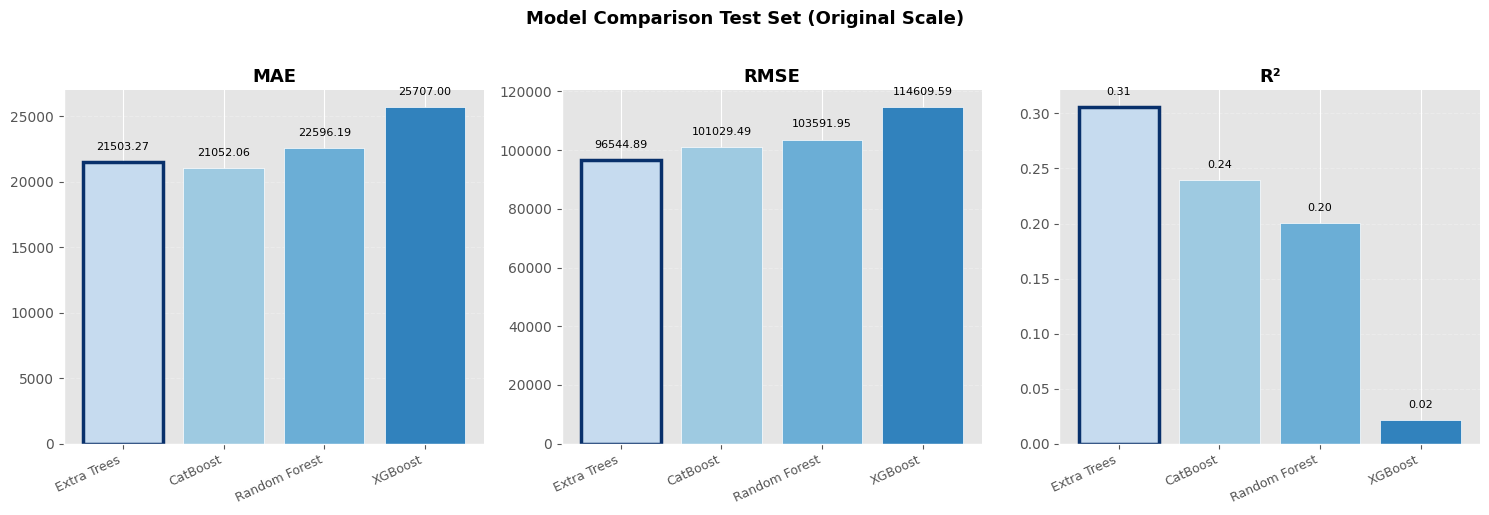

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette = [
    "#c6dbef", "#9ecae1", "#6baed6",
    "#3182bd", "#08519c"
]

best_idx = results_df['R²'].values.argmax()

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = results_df[metric]
    names = results_df['Model']

    bars = ax.bar(names, vals, color=palette, edgecolor='white')

    # highlight best model (by R²)
    bars[best_idx].set_edgecolor('#08306b')
    bars[best_idx].set_linewidth(2.5)

    offset = vals.max() * 0.03

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{val:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)

    ax.grid(axis='y', linestyle='--', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Model Comparison Test Set (Original Scale)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()

## Train Best Model on Full Data & Save

In [25]:
print(f"Training {BEST_NAME} on full dataset...")

# Build state frequency on the FULL dataset (used again at inference time)
state_freq_map_full = (df['State_Name'].value_counts(normalize=True) if HAS_STATE else None)

X_full = df[FEATURE_COLS_PRE_SPLIT].copy()
if HAS_STATE:
    X_full['State_freq'] = df['State_Name'].map(state_freq_map_full)
X_full = X_full[FEATURE_COLS]

# Fit a fresh QuantileTransformer on the FULL target (production model uses all data)
qt_full = QuantileTransformer(output_distribution='normal', random_state=42)
y_full = qt_full.fit_transform(y_raw.values.reshape(-1, 1)).flatten()

best_model = MODELS[BEST_NAME]
best_model.fit(X_full, y_full)

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')
joblib.dump(qt_full, 'quantile_transformer.pkl')
joblib.dump(state_freq_map_full.to_dict() if HAS_STATE else {}, 'state_freq_mapping.pkl')

print(" best_model.pkl saved")
print(" feature_cols.pkl saved")
print(" quantile_transformer.pkl saved")
print(" state_freq_mapping.pkl saved")
print(f"  Features: {FEATURE_COLS}")


Training Extra Trees on full dataset...
 best_model.pkl saved
 feature_cols.pkl saved
 quantile_transformer.pkl saved
 state_freq_mapping.pkl saved
  Features: ['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'Water_Body_Type_POND', 'Water_Body_Type_TANK', 'Water_Body_Type_WETLAND', 'State_freq', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp']


## Predictions + Safe / Not Safe Classification

| Threshold | Label |
|---|---|
| Fecal Coliform ≤ 50 MPN/100 mL |  Safe |
| Fecal Coliform > 50 MPN/100 mL |  Not Safe |

    fitted[BEST_NAME] now stores (model, preds_raw) where preds_raw was already inverse-transformed (expm1) back to original MPN/100mL scale inside fit_and_evaluate()

In [26]:
SAFE_THRESHOLD = 50   # MPN / 100 mL

best_fitted, pred_raw = fitted[BEST_NAME]

pred_label   = pd.Series(pred_raw).apply(lambda x: 'Safe' if x <= SAFE_THRESHOLD else 'Not Safe')
actual_label = y_test_raw.apply(lambda x: 'Safe' if x <= SAFE_THRESHOLD else 'Not Safe')

sample = pd.DataFrame({
    'Actual FC (MPN)'     : y_test_raw.values[:10].round(2),
    'Predicted FC (MPN)'  : pred_raw[:10].round(2),
    'Actual Label'        : actual_label.values[:10],
    'Predicted Label'     : pred_label.values[:10],
})
print("Sample predictions (first 10):")
print(sample.to_string(index=False))

Sample predictions (first 10):
 Actual FC (MPN)  Predicted FC (MPN) Actual Label Predicted Label
         17.5000             29.1400         Safe            Safe
         57.0000            163.2000     Not Safe        Not Safe
        220.0000          14475.8700     Not Safe        Not Safe
        605.0000            330.0000     Not Safe        Not Safe
         27.5000             18.0400         Safe            Safe
      14350.0000           1123.6000     Not Safe        Not Safe
      20042.0000          85169.0300     Not Safe        Not Safe
      23850.0000          20312.8900     Not Safe        Not Safe
       1650.0000            900.0000     Not Safe        Not Safe
         13.5000             26.5100         Safe            Safe


## Classification Report + Confusion Matrix

CLASSIFICATION REPORT (Safe vs Not Safe)
              precision    recall  f1-score   support

    Not Safe       0.93      0.91      0.92       352
        Safe       0.82      0.85      0.84       172

    accuracy                           0.89       524
   macro avg       0.87      0.88      0.88       524
weighted avg       0.89      0.89      0.89       524



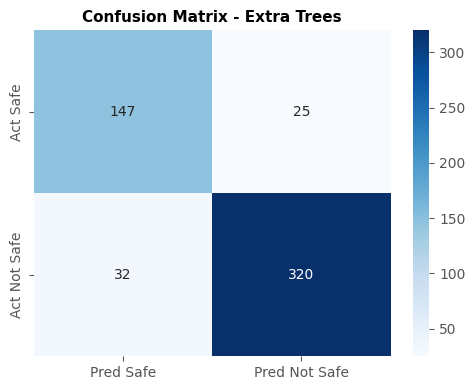

In [27]:
print("CLASSIFICATION REPORT (Safe vs Not Safe)")
print(classification_report(actual_label, pred_label, target_names=['Not Safe','Safe']))

cm = confusion_matrix(actual_label, pred_label, labels=['Safe','Not Safe'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Safe','Pred Not Safe'],
            yticklabels=['Act Safe', 'Act Not Safe'], ax=ax)
ax.set_title(f'Confusion Matrix - {BEST_NAME}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Importance

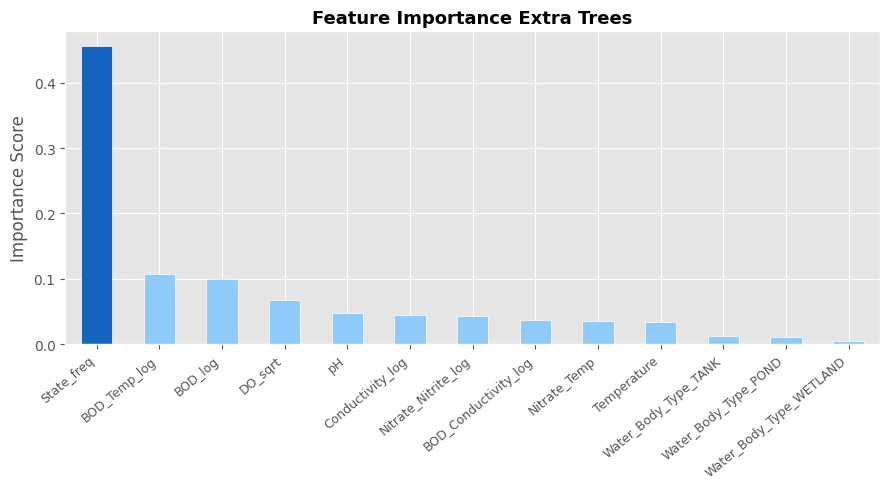

Saved feature_importance.png

Top features:
State_freq     0.4556
BOD_Temp_log   0.1072
BOD_log        0.0999
DO_sqrt        0.0669
pH             0.0472


In [28]:
if hasattr(best_fitted, 'feature_importances_'):
    importances = pd.Series(best_fitted.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(importances))]
    importances.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance {BEST_NAME}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Importance Score')
    ax.set_xticklabels(importances.index, rotation=40, ha='right', fontsize=9)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show();  print("Saved feature_importance.png")
    print("\nTop features:")
    print(importances.head().to_string())
else:
    print(f"{BEST_NAME} does not expose feature_importances_")

## Actual vs Predicted Plot

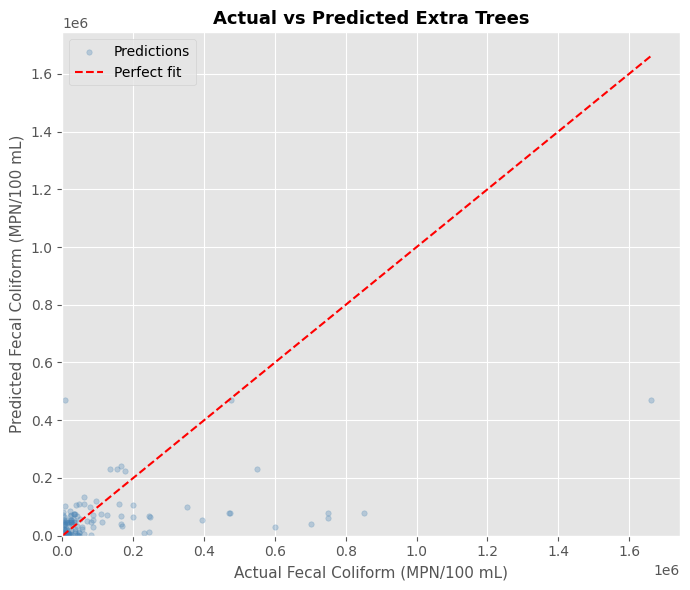

Saved actual_vs_predicted.png


In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_raw, pred_raw, alpha=0.3, s=15, color='steelblue', label='Predictions')
max_v = max(float(y_test_raw.max()), float(pred_raw.max()))
ax.plot([0, max_v], [0, max_v], 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Fecal Coliform (MPN/100 mL)', fontsize=11)
ax.set_ylabel('Predicted Fecal Coliform (MPN/100 mL)', fontsize=11)
ax.set_title(f'Actual vs Predicted {BEST_NAME}', fontsize=13, fontweight='bold')
ax.legend();  ax.set_xlim(left=0);  ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show();  print("Saved actual_vs_predicted.png")

## Pipeline Summary

| Step | Status |
|---|---|
| Load cleaned data (no re-cleaning) | Done |
| Validate required columns exist | Done |
| Encode Water_Body_Type + State_Name | Done |
| Train on log1p(Fecal_Coliform) | Done |
| 5-Fold CV on 4 models | Done |
| Report metrics in original scale | Done |
| Best model saved (.pkl) | Done |
| Safe / Not Safe (threshold = 50) | Done |
| Classification report + confusion matrix | Done |
| Feature importance chart | Done |